## **Causal discovery : a [Causal Chambers](https://www.causalchamber.ai/) Study**

This notebook builds on the **light tunnel** Causal Chamber of Gamella, Peters & Bühlmann (2024).

It uses a **synthetic stand-in dataset**, generated from a
hand-built structural causal model (SCM) designed to mirror the light tunnel's actual physical
structure as described in the paper: a light source (R, G, B) feeds a first sensor (V1, I1);
auxiliary LEDs (L11, L12) contribute weakly and non-linearly there; a first polarizer (theta1)
attenuates the signal reaching a second sensor (V2, I2), with more LEDs (L21, L22) added; a
second polarizer (theta2) attenuates the signal reaching a third sensor (V3, I3), with LEDs
(L31, L32) added there. We also include a nuisance variable `Z_V1` (standing in for the real
system's sensor exposure time) that affects `V1` but **not** `I1` — used later to reproduce the
report's finding that a model relying on a merely-correlated predictor can be broken by an
intervention the causal predictors never see.




In [ ]:
!pip install -q causal-learn causaldag conditional_independence scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.9/245.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 9.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import mutual_info_regression

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.width', 120)


## **Generation of the synthetic light tunnel SCM**

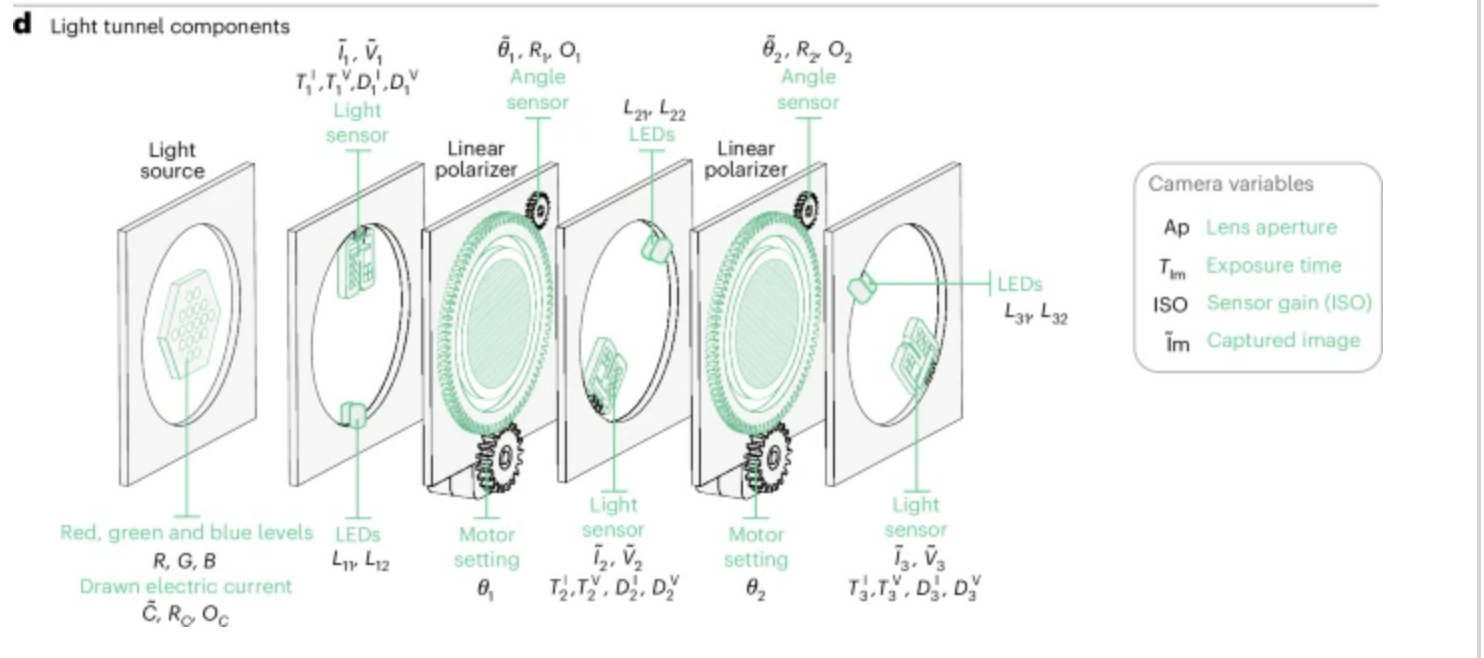

The light tunnel is a small physical device built for the Causal Chambers project. It's a closed, elongated chamber with an adjustable RGB light source at one end, two linear polarizers that motors can rotate to chosen angles, several light sensors along its length, and a camera at the other end that photographs the inside. Everything is controlled, so you can set any input and record the resulting sensor readings and images

We define the structural equations directly (rather than a graph + CPTs), so that we can both
simulate observational data **and** simulate arbitrary single-target interventions by simply overriding one variable's sampling range.


In [ ]:
def sample_environment(n, rng, intervene=None):
    """Draw n samples from the light-tunnel SCM. `intervene` is an optional dict
    {variable_name: (low, high)} that overrides that variable's uniform sampling range
    for this call -- exactly matching the report's single-target intervention design
    (Table 1: e.g. 'uniform_red_mid' shifts R's marginal, all else unchanged)."""
    intervene = intervene or {}

    def u(name, lo, hi):
        if name in intervene:
            lo, hi = intervene[name]
        return rng.uniform(lo, hi, n)

    R = u('R', 0, 85); G = u('G', 0, 85); B = u('B', 0, 85)
    L11 = u('L11', 0, 170); L12 = u('L12', 0, 170)
    L21 = u('L21', 0, 170); L22 = u('L22', 0, 170)
    L31 = u('L31', 0, 170); L32 = u('L32', 0, 170)
    theta1 = u('theta1', -15, 25); theta2 = u('theta2', -15, 25)
    Z_V1 = u('Z_V1', 0.8, 1.2)  # nuisance "exposure-time-like" factor -- affects V1 ONLY
    noise = lambda scale: rng.normal(0, scale, n)

    # Sensor 1 (upstream of both polarizers): driven by R, G, B. L11, L12 contribute
    # weakly and NON-linearly (mirrors the report's finding that the LED effect is
    # exponential in nature and gets masked by the dominant RGB variance).
    I1 = 12*R + 6*G + 3*B + 0.02*np.exp(L11/60) + 0.02*np.exp(L12/60) + noise(60)
    V1 = 9*R + 10*G + 2*B + Z_V1*180 + noise(60)

    # Polarizer 1 attenuates what reaches sensor 2; LEDs L21, L22 added locally there.
    atten1 = 0.5 + 0.5*np.cos(np.deg2rad(2*theta1))
    I2 = 0.9*I1*atten1 + 0.05*L21 + 0.05*L22 + noise(50)
    V2 = 0.9*V1*atten1 + 0.05*L21 + 0.05*L22 + noise(50)

    # Polarizer 2 attenuates what reaches sensor 3; LEDs L31, L32 added there.
    atten2 = 0.5 + 0.5*np.cos(np.deg2rad(2*theta2))
    I3 = 0.9*I2*atten2 + 0.05*L31 + 0.05*L32 + noise(45)
    V3 = 0.9*V2*atten2 + 0.05*L31 + 0.05*L32 + noise(45)

    return pd.DataFrame({
        'R': R, 'G': G, 'B': B, 'L11': L11, 'L12': L12, 'L21': L21, 'L22': L22,
        'L31': L31, 'L32': L32, 'theta1': theta1, 'theta2': theta2, 'Z_V1': Z_V1,
        'V1': V1, 'V2': V2, 'V3': V3, 'I1': I1, 'I2': I2, 'I3': I3,
    })



In [ ]:
# Ground-truth parent sets (used later for evaluating causal discovery and defining the MB)
TRUE_PARENTS = {
    'I1': {'R', 'G', 'B', 'L11', 'L12'},
    'V1': {'R', 'G', 'B', 'Z_V1'},
    'I2': {'I1', 'theta1', 'L21', 'L22'},
    'V2': {'V1', 'theta1', 'L21', 'L22'},
    'I3': {'I2', 'theta2', 'L31', 'L32'},
    'V3': {'V2', 'theta2', 'L31', 'L32'},
}

TRUE_EDGES = {frozenset({p, c}) for c, ps in TRUE_PARENTS.items() for p in ps}
print(f"Ground-truth graph: {len(TRUE_EDGES)} edges over {len(set().union(*TRUE_PARENTS.values(), TRUE_PARENTS.keys()))} variables")


Ground-truth graph: 25 edges over 18 variables


## **Question 1**

## **Question 1a: generate the data, mean and standard deviation of each feature**

## **Question 1-b : what is the correlation of the variable $I_1$ with the other variables?**

## **Exploratory data analysis**


## **Question 2 : calculate the correlation matrix and the pairwise Mutual Information matrix between all variables. Comment**

## **Question 2b : Display the two matrices and comment**

## **Question 3 : global causal discovery: compare PC and GES**

We restrict causal discovery to the variables:
`R, G, B, L11, L12, L21, L22, L31, L32, theta1, theta2, V1, V2, V3, I1, I2, I3` (we drop `Z_V1`,
our synthetic stand-in for a sensor setting, since the  sensor settings are held
constant and excluded from the graph too).


## **Preliminary matrices for evaluation : adjacency matrices and confusion matrices**

In [ ]:
graph_vars = ['R','G','B','L11','L12','L21','L22','L31','L32','theta1','theta2',
              'V1','V2','V3','I1','I2','I3']
df_graph = df_ref[graph_vars]

def edges_from_adjacency(adj, col_names):
    edges = set()
    n = len(col_names)
    for i in range(n):
        for j in range(i+1, n):
            if adj[i, j] != 0 or adj[j, i] != 0:
                edges.add(frozenset({col_names[i], col_names[j]}))
    return edges

def prf(estimated_edges, true_edges=TRUE_EDGES):
    tp = len(estimated_edges & true_edges)
    fp = len(estimated_edges - true_edges)
    fn = len(true_edges - estimated_edges)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return dict(precision=round(prec, 3), recall=round(rec, 3), f1=round(f1, 3))

def prf_on_mb(estimated_edges, target='I1'):
    true_mb_edges = {e for e in TRUE_EDGES if target in e}
    est_mb_edges = {e for e in estimated_edges if target in e}
    return prf(est_mb_edges, true_mb_edges)


## **Evaluation of the PC method**

## **Evaluation of the GES method**